# Complete Guide to Rolling Windows Analysis

This notebook will guide you through analyzing text patterns using the Rolling Windows module. Whether you want to track word frequencies, compare character usage, or visualize how themes change throughout a document, this guide will show you exactly what to do.

> **Tip:** Before diving in, check out the project README for an overview of all components (within the whole module and this class) and how they fit together. This will help you understand the broader workflow and make the most of the Windows class.

## Table of Contents
1. [Setup and Prerequisites](#setup)
2. [Loading Your Text](#loading)
3. [Creating Windows](#windows)
4. [Choosing Your Analysis Type](#analysis)
   - [Counting Patterns](#counts)
   - [Calculating Averages](#averages)
   - [Comparing Ratios](#ratios)
5. [Visualizing Results](#plotting)
   - [Static Plots](#static)
   - [Interactive Plots](#interactive)
6. [Saving Your Work](#saving)

---

<a id="setup"></a>
## 1. Setup and Prerequisites

First, let's set up everything you need. Run this cell once at the beginning:

In [1]:
# Import all necessary components
import spacy
from lexos.rolling_windows import Windows
from lexos.rolling_windows.calculators.counts import Counts
from lexos.rolling_windows.calculators.averages import Averages
from lexos.rolling_windows.calculators.ratios import Ratios
from lexos.rolling_windows.plotters.simple_plotter import SimplePlotter
from lexos.rolling_windows.plotters.plotly_plotter import PlotlyPlotter
import pandas as pd

# Load the English language model
# If this fails, run: python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

print("✓ Setup complete! You're ready to analyze text.")

✓ Setup complete! You're ready to analyze text.


> **Developers note**
    The spaCy model is required for token-based analysis and linguistic pattern matching. For character-only analysis, you could skip this, but it's recommended to load it anyway for flexibility.

---

<a id="loading"></a>
## 2. Loading Your Text

### Option A: Load from a File (Recommended)

In [2]:
# CHANGE THIS: Replace "A_Scandal_in_Bohemia.txt" with your filename
filename = "A_Scandal_in_Bohemia.txt"

try:
    with open(filename, "r", encoding="utf-8") as f:
        raw_text = f.read()
    print(f"✓ Loaded {len(raw_text)} characters from {filename}")
except FileNotFoundError:
    print(f"❌ Could not find {filename}")
    print("Make sure the file is in the same folder as this notebook")

✓ Loaded 51436 characters from A_Scandal_in_Bohemia.txt


### Option B: Paste Text Directly

In [3]:
# Alternative: Paste your text here
pasted_text = """
Your text goes here...
You can paste articles, stories, transcripts, etc.
"""
print(f"✓ Loaded {len(pasted_text)} characters")

✓ Loaded 75 characters


### Text Preparation (Optional but Recommended)

Many analyses work better with clean, normalized text:

In [4]:
# Basic text cleaning
import string

# Make lowercase (easier to match patterns)
text = raw_text.lower()

# Remove numbers (optional)
text = ''.join(char for char in text if not char.isdigit())

# Remove punctuation but keep special characters (like ð in Old English)
# CHANGE THIS: Add any special characters you want to keep
keep_chars = 'ð'  # Example for Old English, note that this doesn't occur in "A Scandal in Bohemia" but is just an example
punct = string.punctuation
text = ''.join(char for char in text if char not in punct or char in keep_chars)

print(f"✓ Cleaned text: {len(text)} characters")
print(f"Preview: {text[:200]}...")

# process text with spaCy for consistency
# This ensures 'doc' is always available regardless of window type
doc = nlp(text[:1000000])  # Limit to 1M chars for memory
print(f"✓ Text processed with spaCy: {len(doc)} tokens")

✓ Cleaned text: 49361 characters
Preview: 



                              a scandal in bohemia

                               arthur conan doyle







                                table of contents
                                     ...
✓ Text processed with spaCy: 9466 tokens


> **Tip: When to Clean Text**  
> - **Clean** when analyzing word patterns or general themes
> - **Don't clean** when analyzing punctuation, capitalization, or formatting

---

<a id="windows"></a>
## 3. Creating Windows

Windows are overlapping segments of your text. Think of it like a sliding frame that moves through your document, creating overlapping "snapshots" of your text.

### Choose Your Window Settings


In [5]:
# DECISION POINT: How do you want to segment your text?

# Option 1: By Characters (good for symbols, punctuation, letter patterns)
window_size = 1000  # CHANGE THIS: How many characters per window
window_type = "characters"

# Option 2: By Words/Tokens (good for word patterns, themes)
# window_size = 100  # CHANGE THIS: How many words per window
# window_type = "tokens"

print(f"✓ Window settings: {window_size} {window_type} per window")

✓ Window settings: 1000 characters per window


> **Special Case: Analyzing by Lines (for Poetry or Structured Text)**
>
> 1. Split your text into lines: `lines = raw_text.strip().split('\n')`
> 2. Use `lines` as your input instead of `text`
> 3. Set `window_type = "tokens"` (each line becomes a token)
> 4. Set `window_size =` number of lines per window
>
> This approach is ideal for analyzing poems, plays, or any text where line structure matters.

### Create the Windows

In [6]:
# Create the Windows object
windows = Windows()

# Create windows based on your chosen type
if window_type == "tokens":
    # Token-based windows require spaCy processed text
    sample_windows = windows(
        input=doc,
        n=window_size,
        window_type=window_type,
        output="strings"  # Human-readable output
    )
else:
    # Character-based windows work with raw text
    sample_windows = windows(
        input=text,
        n=window_size,
        window_type=window_type,
        output="strings"
    )

# Check how many windows were created
# Create a temporary copy just for counting (windows are consumed when used)
temp_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)
window_count = len(list(temp_windows))
print(f"✓ Created {window_count} overlapping windows")
print(f"Each window contains {window_size} {window_type}")

# Note: sample_windows is still unused and ready for analysis

✓ Created 48362 overlapping windows
Each window contains 1000 characters


> **Important: Windows Are Consumed!**  
> After using a windows object once (like converting to a list), you need to create fresh windows for each calculator. This is why we'll create new windows in each analysis section below.

---

<a id="analysis"></a>
## 4. Choosing Your Analysis Type

Now decide what kind of analysis you want to perform:

<a id="counts"></a>
### Option A: Count Patterns (Raw Frequencies)

Use this when you want to know **how many times** patterns appear in each window.

In [7]:
# CHANGE THESE: Your patterns to search for
patterns_to_count = ["a", "e"]  # Example: Common letters
# patterns_to_count = ["love", "hate"]  # Example: Emotional words
# patterns_to_count = ["sherlock", "watson"]  # Example: Character names

# Create fresh windows for counting
count_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Create the calculator and run the analysis
counter = Counts()
counter(
    patterns=patterns_to_count,
    windows=count_windows,
    mode="exact",
    case_sensitive=False
)

# Get results as a DataFrame
count_results = counter.to_df()
print(f"✓ Counted patterns in {len(count_results)} windows")
print("\nSample results (5 random windows):")
print(count_results.sample(5))
print(f"\nTotal occurrences across all windows:")
print(count_results.sum())

✓ Counted patterns in 48362 windows

Sample results (5 random windows):
        a    e
18014  61   85
11444  69   89
1157   58   90
42026  54  107
3588   67   85

Total occurrences across all windows:
a    2830088
e    4374241
dtype: int64


### Advanced Search Modes

The `mode` parameter controls how patterns are matched:

#### 1. Regular Expressions (regex)

In [8]:
# Find all words starting with "sh"
regex_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

regex_counter = Counts()
regex_counter(
    patterns=[r"\bsh\w*"],  # \b = word boundary, \w* = any word characters
    windows=regex_windows,
    mode="regex",
    case_sensitive=False
)

regex_results = regex_counter.to_df()
print("REGEX EXAMPLE - Words starting with 'sh':")
print(f"Found in {len(regex_results)} windows")
print(f"Total occurrences: {regex_results.sum().values[0]}")

REGEX EXAMPLE - Words starting with 'sh':
Found in 48362 windows
Total occurrences: 137881


#### 2. Multi-word Phrases

In [9]:
# Find specific phrases
phrase_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

phrase_counter = Counts()
phrase_counter(
    patterns=["sherlock holmes"],  # Will find this exact phrase
    windows=phrase_windows,
    mode="exact",
    case_sensitive=False
)

phrase_results = phrase_counter.to_df()
print("MULTI-WORD PHRASE EXAMPLE - 'sherlock holmes':")
print(f"Found in {len(phrase_results)} windows")
print(f"Total occurrences: {phrase_results.sum().values[0] if len(phrase_results) > 0 else 0}")

MULTI-WORD PHRASE EXAMPLE - 'sherlock holmes':
Found in 48362 windows
Total occurrences: 10009


#### 3. Linguistic Patterns (requires token windows)

In [10]:
# Find all proper nouns (names, places, etc.)
if window_type == "tokens":
    spacy_windows = windows(
        input=doc,
        n=window_size,
        window_type="tokens",
        output="tokens"  # MUST be tokens for spaCy rules
    )
    
    spacy_counter = Counts()
    spacy_counter(
        patterns=[[{"POS": "PROPN"}]],  # PROPN = proper noun
        windows=spacy_windows,
        mode="spacy_rule",
        model="en_core_web_sm"
    )
    
    spacy_results = spacy_counter.to_df()
    print("LINGUISTIC PATTERN EXAMPLE - Proper nouns:")
    print(f"Found in {len(spacy_results)} windows")
    print(f"Total occurrences: {spacy_results.sum().values[0]}")
else:
    print("LINGUISTIC PATTERN EXAMPLE - Requires token-based windows (skipping)")

LINGUISTIC PATTERN EXAMPLE - Requires token-based windows (skipping)


### More Pattern Examples You Can Try

- **Regex:** `r".*ing$"` — words ending in **-ing**
- **Regex:** `r"\b[A-Z]\w*"` — capitalized words
- **Regex:** `r"\d+"` — numbers
- **Multi-token:** `"the game is afoot"`
- **SpaCy:** `[{"POS": "VERB"}]` — all verbs
- **SpaCy:** `[{"POS": "ADJ"}]` — all adjectives

> **Developer's Note:**  
> - `exact` mode uses Python's string `count()` method
> - `regex` mode uses `re.findall()` with appropriate flags
> - `spacy_rule` mode requires spaCy Token objects, not strings
> - See the project documentation for full pattern matching details

<a id="averages"></a>
### Option B: Calculate Averages (Normalized Frequencies)

Use this when you want to know **how often** patterns appear (frequency per unit). This is better for comparing across different window sizes or texts of different lengths.

In [11]:
# CHANGE THESE: Your patterns to analyze
patterns_to_average = ["a", "e"]  # Same format as counting

# Create fresh windows for averaging
avg_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Create and call the calculator
averager = Averages()
averager(
    patterns=patterns_to_average,
    windows=avg_windows,
    mode="exact",
    case_sensitive=False
)

# Get results
avg_results = averager.to_df()
print(f"✓ Calculated average frequencies in {len(avg_results)} windows")
print("\nRandom 5 windows:")
print(avg_results.sample(5))
print(f"\nOverall average frequency:")
print(avg_results.mean())

✓ Calculated average frequencies in 48362 windows

Random 5 windows:
           a      e
44605  0.059  0.098
46496  0.063  0.097
7023   0.060  0.110
24899  0.068  0.084
16575  0.043  0.084

Overall average frequency:
a    0.058519
e    0.090448
dtype: float64


**When to use Averages instead of Counts:**
- Comparing texts of different lengths
- Comparing different window sizes
- Creating standardized measurements
- Academic/scientific analysis

<a id="ratios"></a>
### Option C: Compare Ratios (Relative Frequencies)

Use this when you want to compare the **balance between exactly two patterns**.

In [12]:
# CHANGE THESE: Exactly 2 patterns to compare
patterns_to_compare = ["a", "e"]  # Will calculate a / (a + e)
# patterns_to_compare = ["positive", "negative"]  # Example: sentiment balance
# patterns_to_compare = ["past", "present"]  # Example: tense analysis

# Create fresh windows for ratios
ratio_windows = windows(
    input=text if window_type == "characters" else doc,
    n=window_size,
    window_type=window_type,
    output="strings"
)

# Create and run the calculator
ratio_calc = Ratios()
ratio_calc(
    patterns=patterns_to_compare,
    windows=ratio_windows,
    mode="exact",
    case_sensitive=False
)

# Get results
ratio_results = ratio_calc.to_df()
print(f"✓ Calculated ratios in {len(ratio_results)} windows")
print("\nSample results (5 random windows):")
print(ratio_results.sample(5))

# Interpret the results
avg_ratio = ratio_results.iloc[:, 0].mean()
print(f"\nAverage ratio: {avg_ratio:.3f}")
if avg_ratio > 0.5:
    print(f"→ '{patterns_to_compare[0]}' appears more frequently overall")
elif avg_ratio < 0.5:
    print(f"→ '{patterns_to_compare[1]}' appears more frequently overall")
else:
    print("→ Both patterns appear equally overall")

✓ Calculated ratios in 48362 windows

Sample results (5 random windows):
            a:e
5588   0.372414
2474   0.391608
30514  0.351145
13819  0.402516
44074  0.389610

Average ratio: 0.393
→ 'e' appears more frequently overall


**Understanding Ratios:**
- **0.0** = Only the second pattern appears
- **0.5** = Both patterns appear equally
- **1.0** = Only the first pattern appears
- Values closer to 0 favor the second pattern
- Values closer to 1 favor the first pattern

> **Important: Ratios Requirement**  
> The Ratios calculator requires exactly 2 patterns. For comparing multiple patterns, use Counts or Averages instead.

---

<a id="plotting"></a>
## 5. Visualizing Results

Now let's create visualizations of your analysis. Choose between static plots (for reports) or interactive plots (for exploration).

<a id="static"></a>
### Option A: Static Plots (SimplePlotter)

**Best for:** Reports, publications, presentations

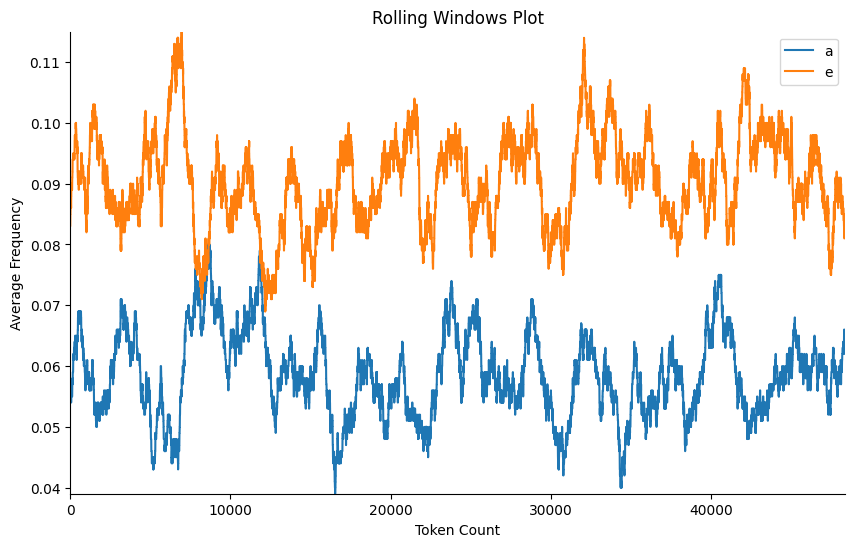

In [13]:
# CHANGE THIS: Use your results from above
data_to_plot = avg_results  # or count_results or ratio_results

# Create a static plot
static_plotter = SimplePlotter(
    title="Pattern Frequency Analysis",  # CHANGE THIS
    xlabel="Window Position",
    ylabel="Frequency",  # CHANGE THIS based on your analysis type
    figsize=(10, 6),  # (width, height) in inches
    show_legend=True,
    show_grid=True
)

# Generate the plot
static_plotter(df=data_to_plot)

# Optional: Save the plot
# static_plotter.save("my_analysis.png", dpi=300)
# static_plotter.save("my_analysis.pdf")  # For publications

#### Adding Milestones (Optional)

Milestones mark important points in your text (like chapter breaks, scene changes, etc.):

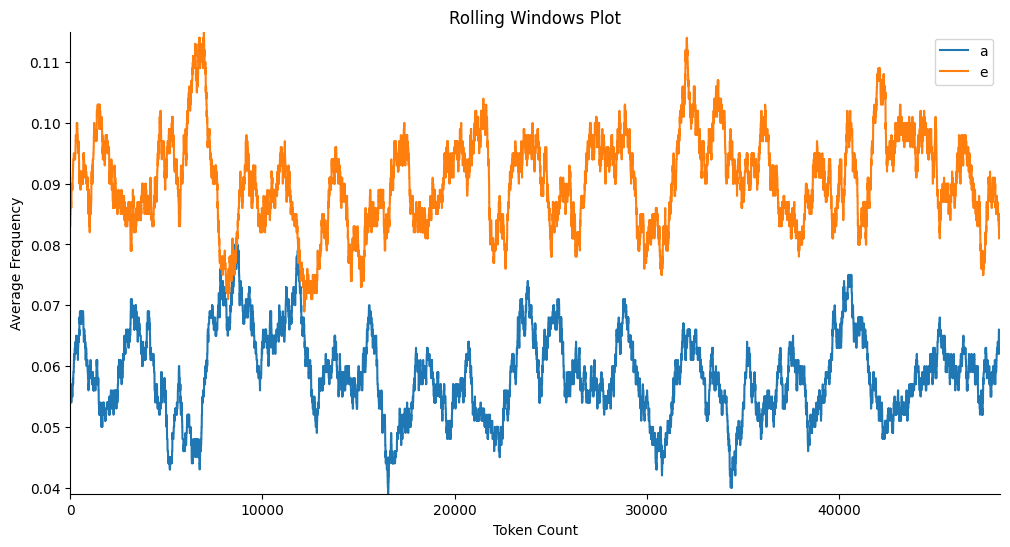

In [14]:
# CHANGE THESE: Define important positions in your text
# You need to figure out which window numbers correspond to important events
milestones = {
    "Chapter 1": 0,      # Window number where Chapter 1 starts
    "Chapter 2": 50,     # Window number where Chapter 2 starts
    "Chapter 3": 100,    # Window number where Chapter 3 starts
}

# Create plot with milestones
milestone_plotter = SimplePlotter(
    title="Analysis with Chapter Markers",
    figsize=(12, 6),
    show_milestones=True,
    milestone_labels=milestones,
    milestone_colors="red",
    milestone_style="--",  # Dashed lines
    show_milestone_labels=True,
    milestone_labels_rotation=45
)

milestone_plotter(df=data_to_plot)

<a id="interactive"></a>
### Option B: Interactive Plots (PlotlyPlotter)

**Best for:** Exploration, web presentation, detailed analysis with hover information

In [15]:
# CHANGE THIS: Use your results from above
data_to_plot = avg_results  # or count_results or ratio_results

# Create an interactive plot
interactive_plotter = PlotlyPlotter(
    title="Interactive Pattern Analysis",  # CHANGE THIS
    xlabel="Window Position",
    ylabel="Frequency",  # CHANGE THIS based on your analysis type
    width=1000,  # pixels
    height=600,  # pixels
    showlegend=True
)

# Generate the plot (displays in notebook)
interactive_plotter(df=data_to_plot)

# Optional: Save as interactive HTML
# interactive_plotter.save("my_analysis.html")

**Interactive Features:**
- **Hover** over points to see exact values
- **Zoom** in/out with mouse wheel or zoom controls
- **Pan** by clicking and dragging
- **Toggle** lines on/off by clicking legend items
- **Download** plot as PNG using the camera icon

> **Tip: Which Plotter to Use?**  
> - **SimplePlotter**: When you need high-quality static images for papers, reports, or presentations
> - **PlotlyPlotter**: When you want to explore the data interactively or share results that others can explore

---

<a id="saving"></a>
## 6. Saving Your Work

Don't forget to save your results for future reference!

### Save the Data

In [16]:
# Save your numerical results as CSV
data_to_plot.to_csv("sample_outputs/sample_analysis_data.csv", index=True)
print("✓ Saved data to sample_analysis_data.csv")

# Create a summary report
summary = pd.DataFrame({
    'Pattern': data_to_plot.columns,
    'Total': data_to_plot.sum().values,
    'Average': data_to_plot.mean().values,
    'Max': data_to_plot.max().values,
    'Min': data_to_plot.min().values,
    'Std_Dev': data_to_plot.std().values
})

print("\n=== SUMMARY REPORT ===")
print(summary)

# Save summary
summary.to_csv("sample_outputs/sample_analysis_summary.csv", index=False)
print("✓ Saved summary to sample_analysis_summary.csv")

✓ Saved data to sample_analysis_data.csv

=== SUMMARY REPORT ===
  Pattern         Total       Average        Max    Min       Std_Dev
0       a  2.830088e+03      0.058519      0.080  0.039      0.006899
1       e  4.374241e+03      0.090448      0.115  0.069      0.007546
2      id  1.169417e+09  24180.500000  48361.000  0.000  13961.051196
✓ Saved summary to sample_analysis_summary.csv


### Save the Plots

In [17]:
# For static plots (SimplePlotter)
if 'static_plotter' in locals():
    static_plotter.save("sample_outputs/sample_analysis_plot.png", dpi=300, bbox_inches='tight')
    static_plotter.save("sample_outputs/sample_analysis_plot.pdf", bbox_inches='tight')
    print("✓ Saved static plots")

# For interactive plots (PlotlyPlotter)
if 'interactive_plotter' in locals():
    interactive_plotter.save("sample_outputs/sample_analysis_interactive.html")
    print("✓ Saved interactive plot as HTML")

✓ Saved static plots
✓ Saved interactive plot as HTML


---

## Complete Example Workflow

Here's everything together in one workflow:

✓ Complete analysis finished!
Analyzed 50437 windows
Average 'a' frequency: 0.0561
Average 'e' frequency: 0.0868


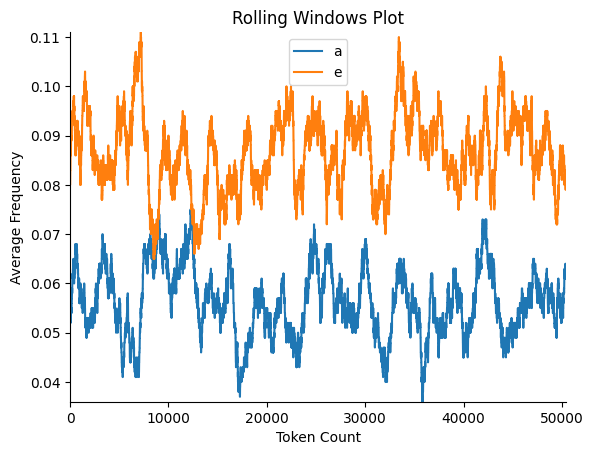

In [18]:
# 1. Load and prepare text
with open("A_Scandal_in_Bohemia.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()

# 2. Create windows (1000 characters each)
windows = Windows()
analysis_windows = windows(input=text, n=1000, window_type="characters", output="strings")

# 3. Calculate average frequencies of 'a' and 'e'
calculator = Averages()
calculator(patterns=["a", "e"], windows=analysis_windows, mode="exact", case_sensitive=False)
results = calculator.to_df()

# 4. Create visualization
plotter = SimplePlotter(title="Letter Frequencies: 'a' vs 'e' in A Scandal in Bohemia")
plotter(df=results)

# 5. Save everything
plotter.save("sample_outputs/Bohemia_analysis.png")
results.to_csv("sample_outputs/Bohemia_data.csv")

print("✓ Complete analysis finished!")
print(f"Analyzed {len(results)} windows")
print(f"Average 'a' frequency: {results['a'].mean():.4f}")
print(f"Average 'e' frequency: {results['e'].mean():.4f}")

---

## Quick Reference

### Analysis Types

| Goal | Calculator | What it measures | Key Setting |
|------|-----------|------------------|-------------|
| Raw occurrences | `Counts` | Total number of matches | `patterns=["word1", "word2"]` |
| Frequency rates | `Averages` | Matches per unit (normalized) | `patterns=["word1", "word2"]` |
| Balance comparison | `Ratios` | Relative proportion | `patterns=["word1", "word2"]` (exactly 2) |

### Window Size Guidelines

| Text Type | Window Type | Suggested Size | Reasoning |
|-----------|-------------|----------------|-----------|
| Short story | characters | 200-500 | Captures local patterns |
| Novel/Book | characters | 500-2000 | Balances detail and trends |
| Short text | tokens | 20-50 | Enough words for patterns |
| Novel/Book | tokens | 50-200 | Captures thematic shifts |
| Poetry | tokens (lines) | 5-20 | Respects verse structure |

### Pattern Matching Examples

| Pattern Type | Example | Mode | Use Case |
|--------------|---------|------|----------|
| Exact match | `["love", "hate"]` | `"exact"` | Simple word counting |
| Word starts with | `[r"^love.*"]` | `"regex"` | Word variations |
| Word ends with | `[r".*ing$"]` | `"regex"` | Grammatical patterns |
| Numbers | `[r"\d+"]` | `"regex"` | Numeric content |
| Capitalized words | `[r"\b[A-Z]\w*"]` | `"regex"` | Proper nouns, sentence starts |
| All nouns | `[[{"POS": "NOUN"}]]` | `"spacy_rule"` | Linguistic analysis |
| Past tense verbs | `[[{"POS": "VERB", "TAG": "VBD"}]]` | `"spacy_rule"` | Temporal analysis |

### Troubleshooting Common Issues

**Problem:** "Windows are consumed" error  
**Solution:** Create fresh windows for each calculator call

**Problem:** spaCy patterns don't work  
**Solution:** Ensure `window_type="tokens"` and `output="tokens"` for spaCy rules

**Problem:** No matches found  
**Solution:** Check case sensitivity, try `case_sensitive=False`

**Problem:** Regex not working  
**Solution:** Use raw strings (`r"pattern"`) and escape special characters

**Problem:** Memory issues with large texts  
**Solution:** Reduce window size or limit text length (e.g., `text[:1000000]`)